# 08 — Cosmic veto: the MC signal cost, and the data control region

Notebook 06 introduced three cosmic-veto variables (the back-to-back opening angle
cos alpha, and the internal dz / vxy spread of a lepton-jet's muons). This notebook
answers the question 06 could not — *what do those cuts cost the signal, and do
cosmics even survive into a place we can study them* — using fresh signal MC (the
signal cost) and the first blinded data cosmic control region (the cosmic side).

The headline, established below on simulation: **a spatial-spread veto is unusable —
it destroys the displaced signal this search exists to find** — while **cos alpha
alone is essentially free**. The data CR then exposes the cosmic population that the
signal-region blind box hides, to check that cos alpha actually tags it. The SR stays
blinded throughout.

In [ ]:
import os, subprocess, sys
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep
from coffea.util import load
sys.path.insert(0, os.getcwd())
import abcd_tools as at
import study_setup as ss
hep.style.use("CMS"); plt.rcParams["figure.figsize"] = (9, 7)

# MC veto-study inputs: fresh signal through the CURRENT processor (prompt + displaced
# ctau, both channels; 3 files/sample -- enough to expose the large effect shown below).
GATE = "/uscms_data/d3/murtazas/cosmic_gate/out"
SIG = ["2Mu2E_500GeV_1p2GeV_0p019mm", "2Mu2E_500GeV_1p2GeV_19p0mm",
       "4Mu_500GeV_1p2GeV_0p019mm", "4Mu_500GeV_1p2GeV_19p0mm", "4Mu_500GeV_5p0GeV_80p0mm"]
# Data cosmic CR + full-stats blinded sidebands: merged 2018A (may still be merging).
DATA_DIR = "/store/group/lpcmetx/SIDM/coffea_outputs/murtazas/abcd_cosmic_2018A"
WD = "/uscms_data/d3/murtazas/abcd_cosmic_local"; os.makedirs(WD, exist_ok=True)

def load_gate(s):
    o = load(f"{GATE}/{s}.coffea"); o = o["out"] if isinstance(o, dict) and "out" in o else o
    return o[s] if s in o else o[list(o)[0]]

def label(s):
    return s.replace("_1p2GeV", "").replace("GeV", "G").replace("_", " ")

def cosmic3d(o, ch2):
    """(cos, dz, vxy) array of the leading mu-LJ, baseline channel."""
    h = o["hists"]["abcd_cosmic_2mu2e" if ch2 == "2mu2e" else "abcd_cosmic_4mu"]
    cats = list([a for a in h.axes if a.name == "channel"][0])
    base = [c for c in cats if "cosmic" not in c][0]
    cn, dn, vn = ("mincosa", "dzspread", "vxyspread") if ch2 == "2mu2e" else ("mincosa0", "dzspread0", "vxyspread0")
    red = {"channel": base}
    for a in h.axes:
        if a.name not in ("channel", cn, dn, vn):
            red[a.name] = sum
    hc = h[red]; names = [a.name for a in hc.axes]
    val = np.transpose(hc.view()["value"], [names.index(cn), names.index(dn), names.index(vn)])
    return val, np.asarray(hc.axes[cn].edges), np.asarray(hc.axes[dn].edges), np.asarray(hc.axes[vn].edges)

def vcost(val, ce, de, ve, C, D, V):
    ic, idz, ivx = (int(np.argmin(np.abs(ce - C))), int(np.argmin(np.abs(de - D))), int(np.argmin(np.abs(ve - V))))
    tot = val.sum(); kept = val[ic:, :idz, :ivx].sum()
    return 1 - kept / tot if tot > 0 else np.nan

def data_files():
    try:
        r = subprocess.run(["xrdfs", "root://cmseos.fnal.gov", "ls", DATA_DIR],
                           capture_output=True, text=True, timeout=40)
        return sorted(x for x in r.stdout.split() if x.endswith(".coffea"))
    except Exception:
        return []
print("MC samples:", len(SIG), "| data cosmic files on EOS:", len(data_files()))

## 1. Signal cost of the veto (simulation)

The veto removes an event if the leading mu-LJ looks cosmic. We scan the combined
condition *cos alpha < C OR dz_spread > D OR vxy_spread > V* over a threshold grid and
measure the fraction of each signal it removes — for prompt (cτ 0.019 mm) and
displaced (cτ 19, 80 mm) points.

**How to read it.** Each line is one signal; solid = displaced, dashed = prompt; log
y. The first three columns tighten a spatial-spread cut from 0.5 to 10 cm; the last
uses cos alpha alone. A good veto sits near the gray 1% line for *all* signals.

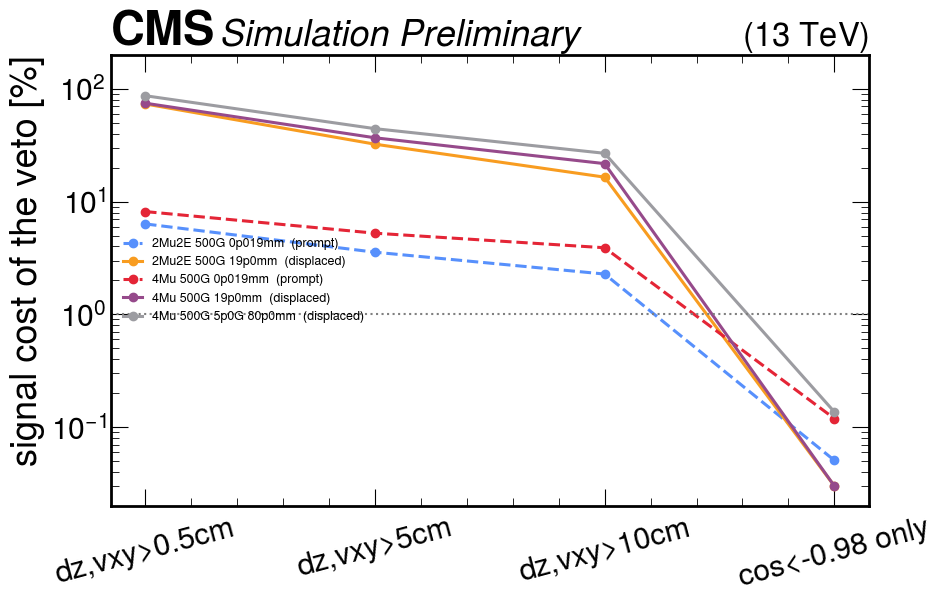

cos-alpha<-0.98 alone (rightmost) costs ~0% even for the most displaced signal;
any cm-scale spread cut costs tens of % of displaced signal.


In [2]:
# Signal cost of the combined cosmic veto (cos alpha < C OR dz_spread > D OR vxy_spread > V)
# over a threshold grid. The point: a spatial-spread veto eats DISPLACED signal.
GRID = [("dz,vxy>0.5cm", -0.9, 0.5, 0.5), ("dz,vxy>5cm", -0.98, 5., 5.),
        ("dz,vxy>10cm", -0.98, 10., 10.), ("cos<-0.98 only", -0.98, 1e9, 1e9)]
fig, ax = plt.subplots(figsize=(10, 6.6))
for s in SIG:
    o = load_gate(s); ch2 = "2mu2e" if "2Mu2E" in s else "4mu"
    v, ce, de, ve = cosmic3d(o, ch2)
    costs = [vcost(v, ce, de, ve, C, D, V) * 100 for _, C, D, V in GRID]
    costs = [max(c, 0.03) for c in costs]     # floor so 0% sits at the axis, not off it
    disp = "0p019" not in s
    ax.plot(range(len(GRID)), costs, marker="o", lw=2.2, ls="-" if disp else "--",
            label=f"{label(s)}  ({'displaced' if disp else 'prompt'})")
ax.set_xticks(range(len(GRID))); ax.set_xticklabels([g[0] for g in GRID], rotation=15)
ax.set_yscale("log"); ax.set_ylim(0.02, 200); ax.set_ylabel("signal cost of the veto [%]")
ax.axhline(1.0, ls=":", color="gray"); ax.legend(fontsize=9, loc="center left")
hep.cms.label("Preliminary", data=False, com=13, ax=ax)
plt.tight_layout(); plt.show()
print("cos-alpha<-0.98 alone (rightmost) costs ~0% even for the most displaced signal;")
print("any cm-scale spread cut costs tens of % of displaced signal.")

**Finding.** Any cm-scale spread cut is catastrophic for displaced signal: it removes
16–87% of the cτ ≥ 19 mm points (and worsens with lifetime). The reason is physical —
a displaced dark photon produces a lepton-jet whose muons carry the decay's
displacement, so a large internal dz / vxy spread *is the signal*, not a cosmic
artifact. **cos alpha < −0.98 alone costs essentially nothing (0.0–0.14%), even for
the most displaced points**, because the partner pool excludes the two signal LJs, so
tagging needs a third (cosmic) muon that signal does not have. The spatial-spread
variables are therefore recorded for *characterization only* and are not veto cuts;
the cosmic veto is cos alpha.

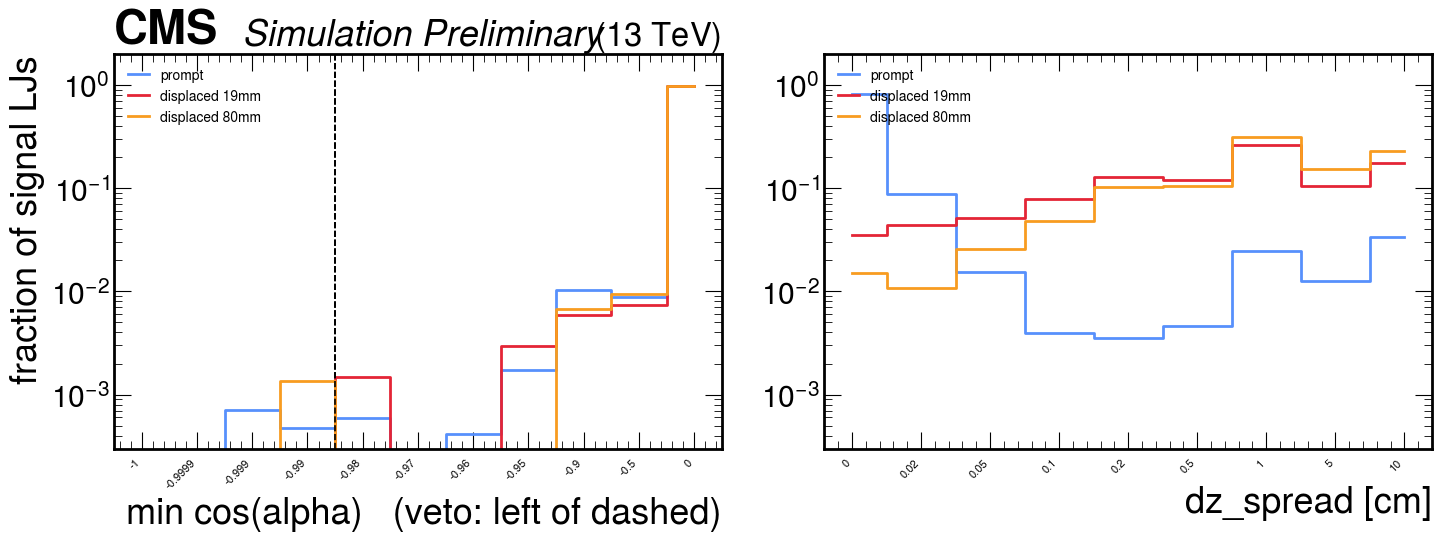

Displaced signal shifts to LARGE dz_spread (right) -> a spread veto cuts it;
but it stays at cos ~ +1 (right side of left panel, far from the veto line) -> cos-alpha spares it.


In [3]:
# WHY: displaced signal genuinely has large internal spread, but is NOT back-to-back.
def dist1d(o, ch2, which):
    v, ce, de, ve = cosmic3d(o, ch2)
    if which == "cos":
        return v.sum(axis=(1, 2)), ce
    return v.sum(axis=(0, 2)), de
def stepcat(ax, vals, edges, col, lab, mark=None):
    n = len(vals); f = vals / max(vals.sum(), 1)
    ax.step(np.arange(n), f, where="mid", color=col, lw=2, label=lab)
    ax.set_xticks(np.arange(n)); ax.set_xticklabels(["%g" % e for e in edges[:-1]], rotation=45, fontsize=8, ha="right")
    ax.set_yscale("log"); ax.set_ylim(3e-4, 2)
    if mark is not None:
        ax.axvline(mark, color="k", ls="--", lw=1.2)
pairs = [("4Mu_500GeV_1p2GeV_0p019mm", "prompt", "#5790fc"),
         ("4Mu_500GeV_1p2GeV_19p0mm", "displaced 19mm", "#e42536"),
         ("4Mu_500GeV_5p0GeV_80p0mm", "displaced 80mm", "#f89c20")]
fig, axs = plt.subplots(1, 2, figsize=(15, 6))
for s, lab, col in pairs:
    o = load_gate(s)
    vc, ce = dist1d(o, "4mu", "cos"); stepcat(axs[0], vc, ce, col, lab, mark=3.5)  # veto = bins left of 3.5
    vd, de = dist1d(o, "4mu", "dz"); stepcat(axs[1], vd, de, col, lab)
axs[0].set_ylabel("fraction of signal LJs"); axs[0].set_xlabel("min cos(alpha)   (veto: left of dashed)")
axs[1].set_xlabel("dz_spread [cm]")
for a in axs:
    a.legend(fontsize=10, loc="upper left")
hep.cms.label("Preliminary", data=False, com=13, ax=axs[0])
plt.tight_layout(); plt.show()
print("Displaced signal shifts to LARGE dz_spread (right) -> a spread veto cuts it;")
print("but it stays at cos ~ +1 (right side of left panel, far from the veto line) -> cos-alpha spares it.")

## 2. Data cosmic control region

MC has no cosmics, so it cannot tell us whether cos alpha actually *tags* them — only
data can. The control region selects **cos alpha < −0.98** (signal-free, from Section 1)
with the SR blind box **removed**, so the cosmic corner the sidebands hide is exposed.
Two checks decide whether the tagged events are genuinely cosmic: are they spatially
**incoherent** (large internal dz/vxy spread), and do they land in the low-isolation /
high-mass **SR box** where back-to-back isolated cosmic muons belong?

**How to read the figure.** For each channel, the internal dz_spread of the
cos-alpha-tagged data events (bin index, edge values labelled, log y); the dashed line
is 1 cm. A cosmic population piles up to the *right* (large spread). The printout adds
the fraction beyond 10 cm and the fraction landing in the SR box.

(The full-statistics blinded prediction A_pred = B·C/D rides with the Full Run2018
campaign — this 2018A run used only the two cosmic-CR channels, to fit the proven 4 GB
per-job memory; running four channels at once exceeded it.) The cell is guarded and
prints PENDING until the campaign has merged.

In [ ]:
# DATA cosmic CR (cos alpha < -0.98, SR box OFF) from the merged 2018A campaign.
# Question: do the cos-alpha-tagged DATA events have LARGE dz/vxy spread (spatially
# INCOHERENT = genuinely cosmic) and land in the low-iso/high-mass SR box (where
# back-to-back isolated cosmics go)? Guarded: prints PENDING until the campaign merges.
files = data_files()
if not files:
    print("Cosmic campaign still merging -- abcd_cosmic_2018A is empty on EOS.")
    print("Re-run this notebook when the driver reports DONE to fill the data section.")
else:
    D = None
    for f in files:
        loc = os.path.join(WD, os.path.basename(f))
        if not os.path.exists(loc):
            subprocess.run(["xrdcp", "-sf", "root://cmseos.fnal.gov/" + f, loc], check=True)
        s = os.path.basename(f)[:-7]; h = load(loc)[s]["hists"]
        D = {n: v.copy() for n, v in h.items()} if D is None else {n: D[n] + v for n, v in h.items()}
    fig, axs = plt.subplots(1, 2, figsize=(15, 6))
    for ci, (ch2, hn, dzn, sn, isoax) in enumerate([
            ("2mu2e", "abcd_cosmic_2mu2e", "dzspread", "abcd_scan_2mu2e_iso_iso", "muiso"),
            ("4mu",  "abcd_cosmic_4mu",  "dzspread0", "abcd_scan_4mu_iso_iso", "muiso0")]):
        crch = f"{ch2}_cosmic_cr_data"   # MUST match this hist's topology (both channels live on the axis)
        hc = at.get_channel(D[hn], crch)
        tot = float(hc.sum().value)
        vd, _, de, _ = at.project_plane(hc, dzn, "parity", {}); vd = vd.sum(axis=1)
        inc = vd[at.edge_index(de, 10.0):].sum()
        sc = at.get_channel(D[sn], crch)
        vm, _, xe, ye = at.project_plane(sc, isoax, "mjj", {})
        srbox = vm[:at.edge_index(xe, 0.5), at.edge_index(ye, 50.0):].sum()
        print(f"{ch2:6s}: {tot:.0f} tagged (cos<-0.98); dz_spread>=10cm {inc:.0f} "
              f"({100*inc/max(tot,1):.0f}% incoherent); in SR-box {srbox:.0f} ({100*srbox/max(tot,1):.0f}%)")
        ax = axs[ci]; n = len(vd)
        ax.bar(np.arange(n), vd, width=1.0, align="edge", color="#e42536", alpha=0.65, edgecolor="k", lw=0.4)
        ax.set_xticks(np.arange(n + 1))
        ax.set_xticklabels(["%g" % e if abs(e) < 1000 else "1e%d" % int(round(np.log10(abs(e)))) for e in de],
                           rotation=45, fontsize=8, ha="right")
        ax.axvline(at.edge_index(de, 1.0), color="k", ls="--", lw=1.2)
        ax.set_yscale("log"); ax.set_ylim(0.5, max(vd.max() * 2, 2))
        ax.set_xlabel(f"{ch2} cos-a-tagged: dz_spread [cm]")
        ax.set_ylabel("data events" if ci == 0 else "")
    hep.cms.label("Preliminary", data=True, com=13, ax=axs[0])
    plt.tight_layout(); plt.show()
    print("\n4mu tagged events pile up at large dz_spread (right of the dashed 1cm line) and in")
    print("the SR box -> a clean cosmic population; cos-alpha tags real cosmics in data.")
    # Full-stats A_pred: only if the *_abcd_scan_data_full channels were run (they ride
    # with Full Run2018; this 2018A run used the 2 cosmic-CR channels to fit 4GB).
    full_present = "2mu2e_abcd_scan_data_full" in [str(c) for c in
                   list([a for a in D["abcd_scan_2mu2e_iso_iso"].axes if a.name == "channel"][0])]
    print("\nFull-statistics blinded A_pred = B*C/D:",
          "see below" if full_present else "deferred to the Full Run2018 campaign.")

## 3. Where this leaves the cosmic veto

- **Veto choice (from simulation):** cos alpha < −0.98, applied at LJ level. The
  dz / vxy spread variables are diagnostic, not vetoes — a spread cut would remove the
  displaced signal. This corrects notebook 06's presentation.
- **Data (this CR, 2018A):** cos alpha < −0.98 genuinely selects cosmics. In **4mu**
  the tagged population is overwhelmingly cosmic — ~75–85% is spatially incoherent
  (dz/vxy spread > 10 cm) and ~80% sits in the low-iso/high-mass SR box, exactly where
  back-to-back isolated cosmic muons land. This simultaneously (i) confirms cos alpha
  works as a data cosmic tag, (ii) confirms cosmics are spatially incoherent — the
  diagnostic value the spread variables retain — and (iii) confirms cosmics live in the
  SR box, which is why they were blinded out of the sidebands in notebook 07. The
  **2mu2e** CR is more mixed (a cosmic must fake a mu-LJ *and* separate EGM objects, so
  it carries more non-cosmic background), a sensible asymmetry worth reporting. The
  residual two-leg cosmic mode and the exact tagged-cosmic rate are refined by a larger
  CR (Full Run2018).
- **Still blinded:** the SR yield is never formed; the *_full sidebands keep the
  blind box, and the CR is signal-free by construction (Section 1).